# 04c — Ordinal confusion heatmaps (test)

**Purpose:** **5×5** matrices for **`score_class`** and **`veg_class`** on the **test** split: **true class (rows)** vs **predicted class (columns)** where prediction = **`argmax(softmax) + 1`**. Cells show **row percentages** (each row sums to **100%**).

This complements **`04_model_evaluation`**: NB04 **MAE** uses the **expected value** of the softmax vs hard 1–5 labels; this notebook shows **where** argmax mistakes land (collapse to one bin, neighbor confusion, tail jumps).

**Prerequisites:** `02_data_preprocessing` split manifests; a saved **`best_mcmae_<RUN_TAG>.keras`** checkpoint. **`EXPERIMENT_CONFIG`** (`exclude_binary`) in `src/label_schema.py` must match **NB03** so `tf.data` matches training.

**Row order:** `test_ds` is built from `test_df['image_path'].tolist()`, so predictions align row-wise with `test_df`.


In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path('../').resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix

from src.label_schema import resolve_label_cols, EXPERIMENT_CONFIG as CFG

# --- Edit RUN_TAG to match your checkpoint ---
RUN_TAG = '20260418_220126'

MODEL_PATH = Path('../models/runs') / RUN_TAG / f'best_mcmae_{RUN_TAG}.keras'
BATCH_SIZE = 8  # match 04_model_evaluation

OUT_DIR = Path('../presentation_visuals_only/eval_ordinal').resolve()
LABELS = [1, 2, 3, 4, 5]


assert MODEL_PATH.exists(), f'Missing checkpoint: {MODEL_PATH.resolve()}'


/Users/starsrain/2025_codeProject/GreenSpace_CNN/.venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
splits_dir = Path('../data/processed/splits')
train_csv = splits_dir / 'train.csv'
test_csv = splits_dir / 'test.csv'

for p in (train_csv, test_csv):
    assert p.exists(), f'Missing split manifest: {p} (run 02 first)'

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

_schema = resolve_label_cols(train_df)
binary_cols = [c for c in _schema['binary_cols'] if c not in CFG['exclude_binary']]
assert binary_cols, 'No *_p binary prob cols after exclusions'

for c in ('shade_class', 'score_class', 'veg_class', 'image_path'):
    assert c in test_df.columns, f'Missing {c} in test.csv'

NUM_SHADE = 2
NUM_SCORE = 5
NUM_VEG = 5


def decode_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32) / 255.0
    return img


def make_ds(df):
    paths = df['image_path'].astype(str).tolist()
    ds_paths = tf.data.Dataset.from_tensor_slices(paths)
    ds_imgs = ds_paths.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)

    y_bin = df[binary_cols].fillna(0.0).astype(np.float32).values
    y_shade = df['shade_class'].fillna(0).astype(np.int32).values
    y_score = df['score_class'].fillna(1).astype(np.int32).values - 1
    y_veg = df['veg_class'].fillna(1).astype(np.int32).values - 1

    y_shade = np.clip(y_shade, 0, NUM_SHADE - 1)
    y_score = np.clip(y_score, 0, NUM_SCORE - 1)
    y_veg = np.clip(y_veg, 0, NUM_VEG - 1)

    ds_labels = tf.data.Dataset.from_tensor_slices({
        'bin_head': y_bin,
        'shade_head': y_shade,
        'score_head': y_score,
        'veg_head': y_veg,
    })
    return tf.data.Dataset.zip((ds_imgs, ds_labels)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


test_ds = make_ds(test_df)
print('test_df:', len(test_df), 'batches:', int(np.ceil(len(test_df) / BATCH_SIZE)))


test_df: 922 batches: 116


In [3]:
model_path = Path(MODEL_PATH).resolve()
model = tf.keras.models.load_model(str(model_path), compile=False)
print('Loaded', model_path)

# Prefer folder name models/runs/<RUN_TAG>/...
parts = model_path.parts
if 'runs' in parts:
    i = parts.index('runs')
    run_tag_out = parts[i + 1] if i + 1 < len(parts) else RUN_TAG
else:
    run_tag_out = RUN_TAG
print('run_tag:', run_tag_out)

Loaded /Users/starsrain/2025_codeProject/GreenSpace_CNN/models/runs/20260418_220126/best_mcmae_20260418_220126.keras
run_tag: 20260418_220126


In [4]:
preds = model.predict(test_ds, verbose=0)
if isinstance(preds, dict):
    pred_score = preds['score_head']
    pred_veg = preds['veg_head']
else:
    pred_score = preds[2]
    pred_veg = preds[3]

y_score_true = test_df['score_class'].fillna(1).astype(int).values
y_veg_true = test_df['veg_class'].fillna(1).astype(int).values
y_score_pred = pred_score.argmax(axis=1) + 1
y_veg_pred = pred_veg.argmax(axis=1) + 1

assert len(y_score_true) == len(y_score_pred) == len(test_df)

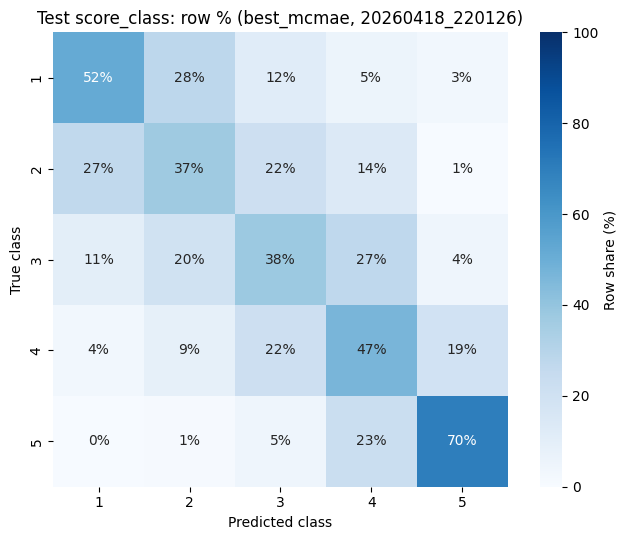

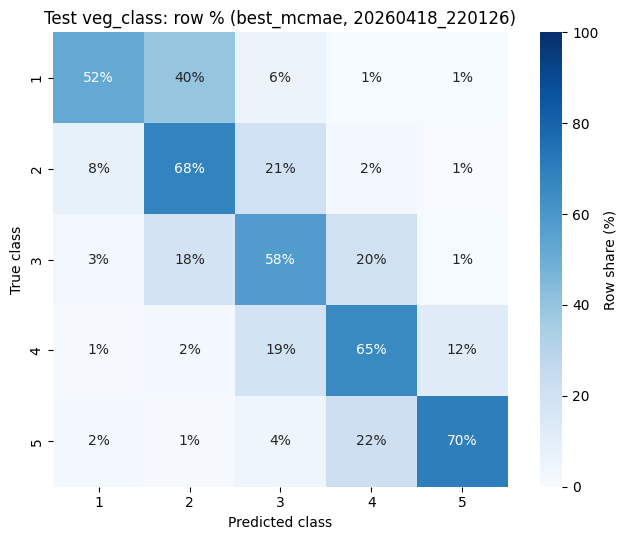

In [7]:
def row_normalized_cm(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    rs = cm.sum(axis=1, keepdims=True)
    rs = np.where(rs == 0, 1, rs)
    return cm, (cm.astype(np.float64) / rs)


def heatmap_figure(cm_norm, title):
    cm_pct = 100.0 * cm_norm
    annot = np.asarray([[f'{v:.0f}%' for v in row] for row in cm_pct], dtype=object)
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(
        cm_pct,
        annot=annot,
        fmt='',
        cmap='Blues',
        vmin=0,
        vmax=100,
        square=True,
        xticklabels=LABELS,
        yticklabels=LABELS,
        ax=ax,
        cbar_kws={'label': 'Row share (%)'},
    )
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    ax.set_title(title)
    fig.tight_layout()
    return fig


_, cm_score_norm = row_normalized_cm(y_score_true, y_score_pred)
_, cm_veg_norm = row_normalized_cm(y_veg_true, y_veg_pred)

TITLE_SCORE = f'Test score_class: row % (best_mcmae, {run_tag_out})'
TITLE_VEG = f'Test veg_class: row % (best_mcmae, {run_tag_out})'
FNAME_SCORE = f'score_confusion_test_{run_tag_out}_best_mcmae.png'
FNAME_VEG = f'veg_confusion_test_{run_tag_out}_best_mcmae.png'

# Review in the notebook before running the next cell to save files.
heatmap_figure(cm_score_norm, TITLE_SCORE)
plt.show()

heatmap_figure(cm_veg_norm, TITLE_VEG)
plt.show()

In [ ]:
# Save PNGs after reviewing the plots in the previous cell.
OUT_DIR.mkdir(parents=True, exist_ok=True)

for cm_norm, title, fname in (
    (cm_score_norm, TITLE_SCORE, FNAME_SCORE),
    (cm_veg_norm, TITLE_VEG, FNAME_VEG),
):
    fig = heatmap_figure(cm_norm, title)
    out_path = OUT_DIR / fname
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    print('Saved', out_path)